# NSQIP Prediction Model Same-day discharge following total hip arthroplasty

## Data Loading

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    roc_curve, auc, confusion_matrix, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier




# Load your dataset
data = pd.read_csv('/Users/janat/NSQIP_New/nsqip_data.csv')
data


,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,prpt,asaclas,prob
0,0,22.500865,female,White,No,Not transferred (admitted from home),62,NO,No,No,...,-99.0,-99.0,4.0,34.9,223.0,-99.0,0.9,-99,1-No Disturb,0.230180
1,0,25.457751,male,White,No,Not transferred (admitted from home),57,NO,No,No,...,-99.0,-99.0,5.8,44.6,148.0,-99.0,1.1,-99,2-Mild Disturb,0.405830
2,0,26.568405,female,White,No,Not transferred (admitted from home),75,NO,No,MODERATE EXERTION,...,30.0,85.0,4.7,39.1,175.0,-99.0,1.0,-99,4-Life Threat,0.002312
3,0,27.432362,female,White,No,Not transferred (admitted from home),63,NO,No,No,...,24.0,80.0,2.3,34.2,103.0,24.0,1.0,-99,2-Mild Disturb,0.028120
4,0,23.672449,male,White,No,Not transferred (admitted from home),39,NO,No,No,...,-99.0,-99.0,5.6,43.7,231.0,-99.0,1.1,-99,1-No Disturb,0.451979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122260,0,34.375340,female,White,No,Not transferred (admitted from home),71,NO,No,No,...,-99.0,-99.0,5.9,39.4,199.0,31.6,1.1,-99,3-Severe Disturb,0.008355
122261,0,25.839830,male,Black or African American,No,Not transferred (admitted from home),57,NO,Yes,No,...,-99.0,-99.0,5.7,42.7,236.0,30.7,1.0,-99,2-Mild Disturb,0.020186
122262,0,37.374330,male,White,No,Outside emergency department,52,NO,No,No,...,36.0,74.0,9.8,41.3,288.0,-99.0,1.0,-99,2-Mild Disturb,0.006117
122263,0,28.120000,female,White,No,Not transferred (admitted from home),84,NO,No,No,...,-99.0,-99.0,8.6,44.4,303.0,-99.0,1.1,-99,3-Severe Disturb,0.048620


## Data Preprocessing

In [7]:
print(data.columns)

Index(['outcome', 'bmi', 'sex', 'race_new', 'ethnicity_hispanic', 'transt',
       'age', 'diabetes', 'smoke', 'dyspnea', 'fnstatus2', 'ventilat',
       'hxcopd', 'ascites', 'hxchf', 'hypermed', 'renafail', 'dialysis',
       'discancr', 'steroid', 'wtloss', 'bleeddis', 'prsodm', 'prbun',
       'prcreat', 'pralbum', 'prbili', 'prsgot', 'pralkph', 'prwbc', 'prhct',
       'prplate', 'prptt', 'prinr', 'prpt', 'asaclas', 'prob'],
      dtype='object')


In [8]:
data = data.drop(columns=['prob','prpt'])
print("Columns:")
print(data.columns)

print("\nShape:")
print(data.shape)


Columns:
Index(['outcome', 'bmi', 'sex', 'race_new', 'ethnicity_hispanic', 'transt',
       'age', 'diabetes', 'smoke', 'dyspnea', 'fnstatus2', 'ventilat',
       'hxcopd', 'ascites', 'hxchf', 'hypermed', 'renafail', 'dialysis',
       'discancr', 'steroid', 'wtloss', 'bleeddis', 'prsodm', 'prbun',
       'prcreat', 'pralbum', 'prbili', 'prsgot', 'pralkph', 'prwbc', 'prhct',
       'prplate', 'prptt', 'prinr', 'asaclas'],
      dtype='object')

Shape:
(122265, 35)


## NSQIP Data Statistics

In [13]:
def create_statistics_summary(df, outcome_col, categorical_cols, numerical_cols):
    rows = []

    # Replace -99 with NaN
    df = df.replace(-99, np.nan)

    # Convert columns safely
    df[categorical_cols] = df[categorical_cols].astype(str)
    df[numerical_cols] = df[numerical_cols].apply(pd.to_numeric, errors='coerce')

    total_0 = df[df[outcome_col] == 0].shape[0]
    total_1 = df[df[outcome_col] == 1].shape[0]

    # CATEGORICAL VARIABLES
    for var in categorical_cols:
        try:
            contingency_table = pd.crosstab(df[var], df[outcome_col])
            _, p_val, _, _ = chi2_contingency(contingency_table)
        except:
            p_val = np.nan

        for cat in df[var].dropna().unique():
            count_0 = df[(df[outcome_col] == 0) & (df[var] == cat)].shape[0]
            count_1 = df[(df[outcome_col] == 1) & (df[var] == cat)].shape[0]

            pct_0 = f"{count_0} ({(count_0 / total_0 * 100):.1f}%)" if total_0 > 0 else ""
            pct_1 = f"{count_1} ({(count_1 / total_1 * 100):.1f}%)" if total_1 > 0 else ""

            rows.append({
                "Variable": var,
                "Category": cat,
                "Statistic": "Count (%)",
                "Class 0": pct_0,
                "Class 1": pct_1,
                "p-value": f"{p_val:.4e}" if pd.notna(p_val) else ""
            })

    # NUMERICAL VARIABLES
    for var in numerical_cols:
        group_0 = df[df[outcome_col] == 0][var].dropna()
        group_1 = df[df[outcome_col] == 1][var].dropna()

        mean0, std0 = group_0.mean(), group_0.std()
        mean1, std1 = group_1.mean(), group_1.std()

        val_0 = f"{mean0:.2f} ± {std0:.2f}" if not np.isnan(mean0) else ""
        val_1 = f"{mean1:.2f} ± {std1:.2f}" if not np.isnan(mean1) else ""

        if len(group_0) > 1 and len(group_1) > 1:
            _, p_val = ttest_ind(group_0, group_1, nan_policy='omit')
        else:
            p_val = np.nan

        rows.append({
            "Variable": var,
            "Category": "—",
            "Statistic": "Mean ± SD",
            "Class 0": val_0,
            "Class 1": val_1,
            "p-value": f"{p_val:.4e}" if pd.notna(p_val) else ""
        })

    summary = pd.DataFrame(rows)
    summary.fillna("", inplace=True)
    return summary


In [15]:
#Usage:

categorical_columns = [
    'sex','race_new','ethnicity_hispanic', 'transt','diabetes','smoke','dyspnea','fnstatus2','ventilat','hxcopd','ascites','hxchf','hypermed','renafail','dialysis','discancr','steroid','wtloss','bleeddis','asaclas',]

numerical_columns = [
    'bmi','age','prsodm','prbun','prcreat','pralbum','prbili','prsgot','pralkph','prwbc','prhct','prplate','prptt','prinr']

summary_df = create_statistics_summary(data, 'outcome', categorical_columns, numerical_columns)
#print(summary_df.to_string(index=False))
summary_df.columns = ['Features', 'Category', 'Statistic', 'Class0', 'Class1', 'p-value']
print(summary_df.to_csv(sep='\t', index=False))
summary_df.to_csv('/Users/janat/NSQIP_New/summary_df.csv', sep='\t',index=False)



Features	Category	Statistic	Class0	Class1	p-value
sex	female	Count (%)	63114 (55.4%)	4001 (48.2%)	1.2721e-36
sex	male	Count (%)	50854 (44.6%)	4294 (51.8%)	1.2721e-36
sex	non-binary	Count (%)	1 (0.0%)	1 (0.0%)	1.2721e-36
race_new	White	Count (%)	79662 (69.9%)	6430 (77.5%)	1.0571e-133
race_new	Native Hawaiian or Pacific Islander	Count (%)	256 (0.2%)	30 (0.4%)	1.0571e-133
race_new	Black or African American	Count (%)	9255 (8.1%)	483 (5.8%)	1.0571e-133
race_new	Asian	Count (%)	1459 (1.3%)	294 (3.5%)	1.0571e-133
race_new	Unknown/Not Reported	Count (%)	22873 (20.1%)	1044 (12.6%)	1.0571e-133
race_new	American Indian or Alaska Native	Count (%)	464 (0.4%)	15 (0.2%)	1.0571e-133
ethnicity_hispanic	No	Count (%)	87113 (76.4%)	6890 (83.1%)	3.2244e-71
ethnicity_hispanic	Yes	Count (%)	3690 (3.2%)	374 (4.5%)	3.2244e-71
ethnicity_hispanic	Unknown	Count (%)	23166 (20.3%)	1032 (12.4%)	3.2244e-71
transt	Not transferred (admitted from home)	Count (%)	112364 (98.6%)	8274 (99.7%)	1.0753e-16
transt	Nursing home

## Data Preprocessing

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_dataframe(df, categorical_columns, numerical_columns):
    """
    Preprocess a DataFrame by handling missing values, encoding categorical variables,
    and normalizing numerical data.

    Parameters:
    - df (pd.DataFrame): Input DataFrame.
    - categorical_columns (list): List of column names that are categorical.
    - numerical_columns (list): List of column names that are numerical.

    Returns:
    - pd.DataFrame: Preprocessed DataFrame.
    """

    df = df.copy()

    # Ensure numerical columns are numeric, convert errors to NaN
    for col in numerical_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing values in numerical columns with column means
    for col in numerical_columns:
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)

    # Fill missing values in categorical columns with 'Unknown' and cast to string
    for col in categorical_columns:
        df[col] = df[col].fillna('Unknown').astype(str)

    # Apply Label Encoding to categorical columns
    label_encoder = LabelEncoder()
    for col in categorical_columns:
        df[col] = label_encoder.fit_transform(df[col])

    # Clip large values to avoid float32 overflow
    for col in numerical_columns:
        max_val = np.finfo(np.float32).max
        df[col] = np.clip(df[col], -max_val, max_val)

    return df

In [18]:
df = preprocess_dataframe(data, categorical_columns, numerical_columns)
df

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
0,0,22.500865,0,5,0,1,62.0,1,0,2,...,-99.0,-99.0,-99.0,-99.0,4.0,34.9,223.0,-99.0,0.9,0
1,0,25.457751,1,5,0,1,57.0,1,0,2,...,-99.0,-99.0,-99.0,-99.0,5.8,44.6,148.0,-99.0,1.1,1
2,0,26.568405,0,5,0,1,75.0,1,0,1,...,-99.0,0.7,30.0,85.0,4.7,39.1,175.0,-99.0,1.0,3
3,0,27.432362,0,5,0,1,63.0,1,0,2,...,4.0,0.3,24.0,80.0,2.3,34.2,103.0,24.0,1.0,1
4,0,23.672449,1,5,0,1,39.0,1,0,2,...,-99.0,-99.0,-99.0,-99.0,5.6,43.7,231.0,-99.0,1.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122260,0,34.375340,0,5,0,1,71.0,1,0,2,...,-99.0,-99.0,-99.0,-99.0,5.9,39.4,199.0,31.6,1.1,2
122261,0,25.839830,1,2,0,1,57.0,1,1,2,...,-99.0,-99.0,-99.0,-99.0,5.7,42.7,236.0,30.7,1.0,1
122262,0,37.374330,1,5,0,3,52.0,1,0,2,...,4.2,0.5,36.0,74.0,9.8,41.3,288.0,-99.0,1.0,1
122263,0,28.120000,0,5,0,1,84.0,1,0,2,...,-99.0,-99.0,-99.0,-99.0,8.6,44.4,303.0,-99.0,1.1,2


## Missing Value adjustment

In [20]:


def replace_neg99_with_local_avg(df, window=2, placeholder=-99):
    df_copy = df.copy()
    numeric_cols = df_copy.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        col_values = df_copy[col].values
        indices_to_replace = np.where(col_values == placeholder)[0]
        
        for idx in indices_to_replace:
            # Define neighborhood boundaries
            start = max(0, idx - window)
            end = min(len(col_values), idx + window + 1)
            
            # Get neighborhood excluding placeholder
            neighborhood = col_values[start:end]
            neighborhood = neighborhood[neighborhood != placeholder]
            
            if len(neighborhood) > 0:
                replacement_value = neighborhood.mean()
            else:
                # fallback to column mean excluding placeholder
                valid_vals = col_values[col_values != placeholder]
                replacement_value = valid_vals.mean() if len(valid_vals) > 0 else 0
            
            col_values[idx] = replacement_value
        
        df_copy[col] = col_values
    
    return df_copy

In [21]:
before_smote_cleandf= replace_neg99_with_local_avg(df, window=2, placeholder=-99)
before_smote_cleandf

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
0,0,22.500865,0,5,0,1,62.0,1,0,2,...,4.142405,0.700000,30.000000,85.000000,4.0,34.9,223.0,29.450804,0.90,0
1,0,25.457751,1,5,0,1,57.0,1,0,2,...,4.071202,0.566667,28.000000,83.333333,5.8,44.6,148.0,26.725402,1.10,1
2,0,26.568405,0,5,0,1,75.0,1,0,1,...,4.071202,0.700000,30.000000,85.000000,4.7,39.1,175.0,26.725402,1.00,3
3,0,27.432362,0,5,0,1,63.0,1,0,2,...,4.000000,0.300000,24.000000,80.000000,2.3,34.2,103.0,24.000000,1.00,1
4,0,23.672449,1,5,0,1,39.0,1,0,2,...,4.035601,0.500000,27.000000,82.500000,5.6,43.7,231.0,25.362701,1.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122260,0,34.375340,0,5,0,1,71.0,1,0,2,...,4.117618,0.491718,21.610983,94.199588,5.9,39.4,199.0,31.600000,1.10,2
122261,0,25.839830,1,2,0,1,57.0,1,1,2,...,4.132562,0.492901,24.031636,90.679012,5.7,42.7,236.0,30.700000,1.00,1
122262,0,37.374330,1,5,0,3,52.0,1,0,2,...,4.200000,0.500000,36.000000,74.000000,9.8,41.3,288.0,31.150000,1.00,1
122263,0,28.120000,0,5,0,1,84.0,1,0,2,...,3.977521,0.530967,24.010545,83.226337,8.6,44.4,303.0,30.925000,1.10,2


## Counting of Positive (Class 1) and Negative data (Class 0) based on outcome!!
Here, we are dealing with an imbalanced dataset

In [23]:
group_counts = before_smote_cleandf['outcome'].value_counts()
print("Group counts:\n", group_counts)

Group counts:
 outcome
0    113969
1      8296
Name: count, dtype: int64


## Training set & Blind set

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
before_smote_cleandf = before_smote_cleandf.copy()  # Replace with your actual path

# Define target column
target_column = 'outcome'

# Stratified 80/20 split directly on the full DataFrame
strain_df, blind_df = train_test_split(
    before_smote_cleandf,
    test_size=0.20,
    stratify=df[target_column],  # still preserves class proportions
    random_state=42
)

# ✅ Print basic sizes
print(f"Strain (training) size: {strain_df.shape}")
print(f"Blind test size: {blind_df.shape}")

# 🔍 Check outcome class distribution
print("\n✅ Outcome Class Distribution in Strain Set:")
print(strain_df[target_column].value_counts(normalize=True).rename_axis('class').reset_index(name='proportion'))

print("\n✅ Outcome Class Distribution in Blind Test Set:")
print(blind_df[target_column].value_counts(normalize=True).rename_axis('class').reset_index(name='proportion'))

# ⚠️ Warn if imbalance detected
def check_class_balance(strain, blind, threshold=0.05):
    strain_dist = strain[target_column].value_counts(normalize=True)
    blind_dist = blind[target_column].value_counts(normalize=True)

    imbalance_detected = False
    for cls in strain_dist.index:
        strain_ratio = strain_dist[cls]
        blind_ratio = blind_dist.get(cls, 0)
        diff = abs(strain_ratio - blind_ratio)
        if diff > threshold:
            print(f"\n⚠️ Warning: Class '{cls}' imbalance detected between strain and blind sets (diff = {diff:.2f})")
            imbalance_detected = True

    if not imbalance_detected:
        print("\n✅ Class distributions between strain and blind sets are well balanced.")

check_class_balance(strain_df, blind_df)

Strain (training) size: (97812, 35)
Blind test size: (24453, 35)

✅ Outcome Class Distribution in Strain Set:
   class  proportion
0      0    0.932145
1      1    0.067855

✅ Outcome Class Distribution in Blind Test Set:
   class  proportion
0      0    0.932156
1      1    0.067844

✅ Class distributions between strain and blind sets are well balanced.


## Training set

In [31]:
strain_df

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
61190,0,24.823249,1,5,0,1,61.0,1,1,2,...,4.000000,0.600000,16.000000,47.000000,7.40,45.1,293.0,31.177778,1.135185,1
62373,0,31.780592,0,2,0,1,80.0,1,0,2,...,4.200000,0.600000,32.000000,98.000000,7.60,41.8,321.0,21.300000,1.050000,2
98952,0,20.045440,0,5,0,1,47.0,1,0,2,...,4.600000,0.800000,17.000000,73.000000,5.60,45.0,182.0,26.525000,1.050000,0
23652,0,20.466036,0,5,0,1,67.0,1,0,2,...,4.300000,0.800000,21.000000,41.000000,3.50,37.5,235.0,26.790701,1.000000,1
57961,0,45.511019,1,5,0,1,42.0,1,1,2,...,3.915972,0.500000,17.520833,93.565972,7.80,36.4,211.0,26.077302,1.036758,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41303,0,28.147461,1,5,0,1,52.0,1,0,2,...,3.400000,0.400000,46.000000,92.000000,9.66,38.8,364.0,31.210562,1.039524,3
101773,0,38.573390,0,5,0,1,79.0,1,0,2,...,4.127915,0.434259,25.558128,74.391804,7.80,36.8,417.0,27.943056,0.986111,2
29968,0,28.645663,1,4,1,1,57.0,1,0,2,...,4.030724,0.453068,34.845703,71.215318,7.63,47.0,211.0,33.089352,1.019138,2
100966,0,45.415460,1,4,1,1,66.0,1,0,2,...,4.400000,0.650000,34.250000,67.875000,7.10,43.0,223.0,28.000000,1.130000,2


## Blind set

In [33]:
blind_df

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
5419,0,27.562486,0,4,1,1,53.0,1,0,2,...,4.800000,0.300000,20.000000,58.000000,7.30,40.9,401.0,28.000000,1.000000,0
86087,0,40.241600,0,5,0,1,62.0,1,0,2,...,3.916667,0.416667,17.583333,86.666667,3.73,40.8,178.0,26.999588,2.600000,1
89329,0,28.888200,0,5,0,1,65.0,1,1,2,...,3.900000,0.400000,22.777778,68.222222,8.64,48.1,217.0,27.766667,1.044444,1
14759,0,34.893172,0,5,0,1,76.0,1,0,2,...,4.500000,0.400000,11.000000,73.000000,35.70,39.9,197.0,25.400000,1.110000,2
111329,0,26.638810,1,5,0,1,82.0,1,0,2,...,4.366667,1.619136,24.358025,74.641975,6.85,42.3,262.0,25.066565,0.980894,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37095,0,32.383002,1,5,0,1,75.0,1,0,2,...,4.200000,0.500000,17.000000,74.000000,4.10,39.8,171.0,29.300000,1.000000,1
79709,0,33.468020,0,5,0,1,59.0,1,0,2,...,4.133604,0.823045,21.604944,79.751046,4.70,40.8,278.0,25.584021,1.274577,1
71072,0,29.444069,0,5,1,1,67.0,1,1,2,...,3.499609,0.992386,25.249392,79.864148,6.92,39.0,423.0,33.000000,0.900000,1
79905,0,25.457750,0,5,0,1,77.0,2,0,2,...,3.977778,0.555556,22.111111,103.555556,8.90,43.4,224.0,23.926090,0.900000,2


## PCA Analysis

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

def plot_pca(df, target_column='outcome', title='PCA Plot', save_path=None):
    """
    Generates and optionally saves a 2D PCA plot colored by class labels.
    Class 0 = blue, Class 1 = red (more classes will be auto-colored)

    Parameters:
    - df: pd.DataFrame containing features and target.
    - target_column: str, name of the label column.
    - title: str, title of the plot.
    - save_path: str or None, file path to save the plot.

    Returns:
    - None
    """
    # Separate features and labels
    features = df.drop(columns=[target_column])
    labels = df[target_column].astype(int)

    # Standardize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    # Perform PCA
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(scaled_features)

    # Set up colors and labels
    predefined_colors = {0: 'blue', 1: 'red'}
    unique_classes = sorted(labels.unique())
    color_list = plt.cm.tab10.colors  # fallback colormap for >2 classes

    plt.figure(figsize=(8, 6))
    for i, class_value in enumerate(unique_classes):
        color = predefined_colors.get(class_value, color_list[i % len(color_list)])
        mask = labels == class_value
        plt.scatter(
            pca_components[mask, 0],
            pca_components[mask, 1],
            label=f'Class {class_value}',
            alpha=0.7,
            edgecolors='k',
            s=60,
            color=color
        )

    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
        print(f"✅ PCA plot saved to: {save_path}")

    plt.show()
    plt.close()


## PCA of Training set 

✅ PCA plot saved to: /Users/janat/NSQIP_New/plots/pca_before_smote_trainingdata.png


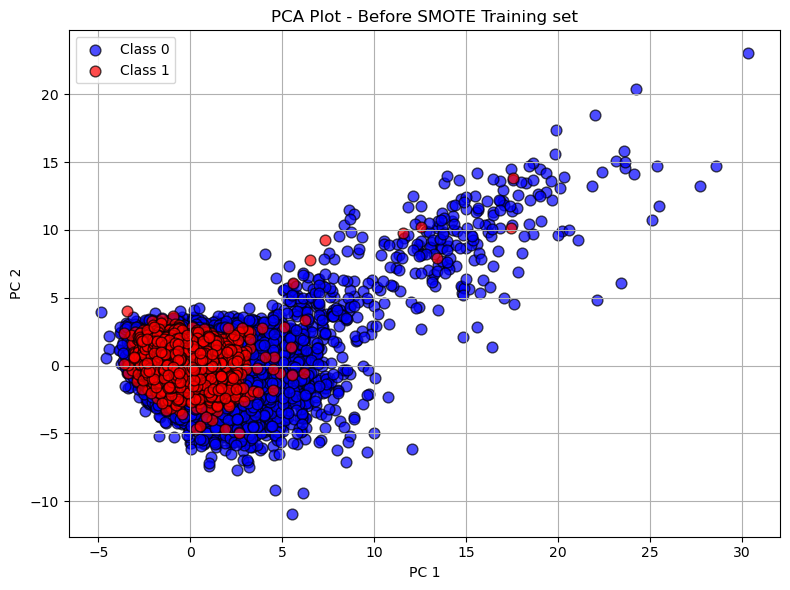

In [43]:


plot_pca(strain_df,
    target_column='outcome',
    title='PCA Plot - Before SMOTE Training set',
    save_path='/Users/janat/NSQIP_New/plots/pca_before_smote_trainingdata.png')




## PCA of Blind set 


✅ PCA plot saved to: /Users/janat/NSQIP_New/plots/pca_before_smote_blindset.png


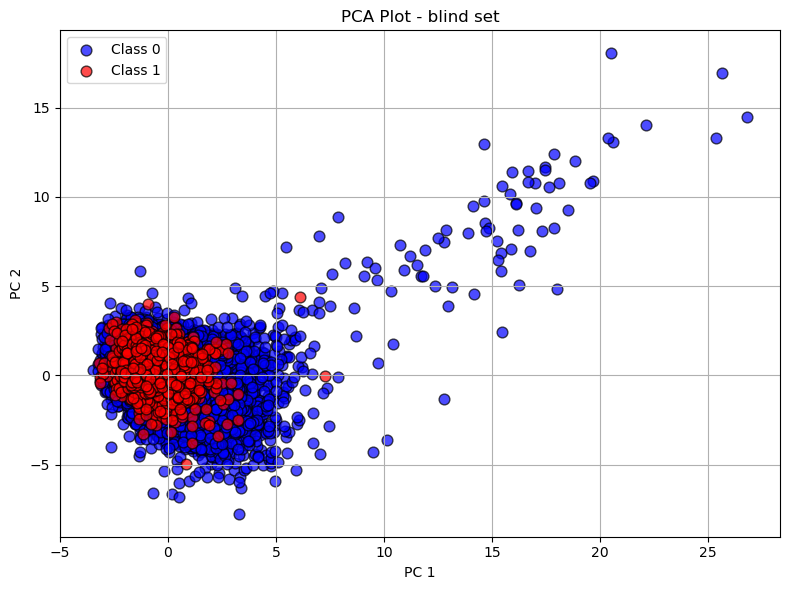

In [45]:


plot_pca(blind_df,
    target_column='outcome',
    title='PCA Plot - blind set',
    save_path='/Users/janat/NSQIP_New/plots/pca_before_smote_blindset.png')




## Before SMOTE Cross Validation


🔍 Classifier: RandomForest
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC
1	0.9321	0.4661	0.5000	0.4824	0.7480	1.0000	0.0000	0.0000
2	0.9322	0.9661	0.5008	0.4840	0.7421	1.0000	1.0000	0.0375
3	0.9322	0.9661	0.5004	0.4832	0.7446	1.0000	1.0000	0.0265
4	0.9322	0.4661	0.5000	0.4824	0.7449	1.0000	0.0000	0.0000
5	0.9323	0.9662	0.5011	0.4847	0.7297	1.0000	1.0000	0.0459
Avg	0.9322	0.7661	0.5005	0.4834	0.7419	1.0000	0.6000	0.0220
✅ Saved best model for RandomForest at: /Users/janat/NSQIP_New/models/presmote/models/RandomForest_best_model.pkl
Blindset	0.9322	0.9661	0.5003	0.4831	0.7456	1.0000	1.0000	0.0237

🔍 Classifier: LogisticRegression
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC
1	0.6140	0.5351	0.6337	0.4672	0.6870	0.6109	0.1094	0.1369
2	0.6153	0.5371	0.6418	0.4697	0.6944	0.6112	0.1119	0.1452
3	0.6180	0.5384	0.6466	0.4720	0.6954	0.6135	0.1135	0.1501
4	0.6142	0.5368	0.6407	0.4689	0.6916	0.6100	0.1113	0.1440
5	0.6109	0.5344	0.6316	0.4652	0.6850	0.6077	0.1084	0.1346
Avg	0.6145	0.5364	0.6389	0.4686	0.690

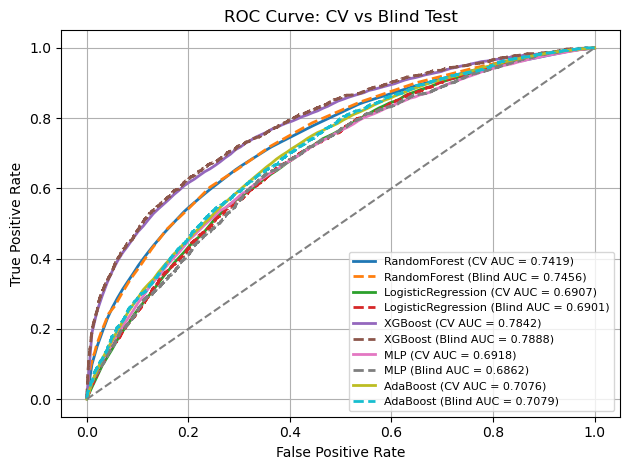

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    average_precision_score, matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ------------------- Data Preparation -------------------
# Assuming strain_df and blind_df are preloaded pandas DataFrames
X = strain_df.drop(columns=['outcome'])
y = strain_df['outcome']

# Drop non-numeric columns and scale features
X = X.drop(columns=X.select_dtypes(include=['object', 'category']).columns)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Prepare blind set data similarly
X_blind = blind_df.drop(columns=['outcome'])
y_blind = blind_df['outcome']
X_blind = X_blind.drop(columns=X_blind.select_dtypes(include=['object', 'category']).columns)
X_blind = pd.DataFrame(scaler.transform(X_blind), columns=X.columns)

# ------------------- Classifier Setup -------------------
classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create directory for saving models
save_dir = "/Users/janat/NSQIP_New/models/presmote/models"
os.makedirs(save_dir, exist_ok=True)

# ------------------- Evaluation -------------------
for name, clf in classifiers.items():
    print(f"\n🔍 Classifier: {name}")
    print("Fold\tAcc\tPrec\tRecall\tF1\tAUC\tSpec\tPPV\tMCC")

    tprs, aucs, pr_aucs = [], [], []
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    spec_list, ppv_list, mcc_list = [], [], []
    mean_fpr = np.linspace(0, 1, 100)
    mean_recall = np.linspace(0, 1, 100)

    best_auc = 0
    best_model = None

    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        precision = report["macro avg"]["precision"]
        recall = report["macro avg"]["recall"]
        f1 = report["macro avg"]["f1-score"]
        mcc = matthews_corrcoef(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)

        print(f"{i+1}\t{acc:.4f}\t{precision:.4f}\t{recall:.4f}\t{f1:.4f}\t{roc_auc:.4f}\t{specificity:.4f}\t{ppv:.4f}\t{mcc:.4f}")

        acc_list.append(acc)
        prec_list.append(precision)
        rec_list.append(recall)
        f1_list.append(f1)
        aucs.append(roc_auc)
        pr_aucs.append(pr_auc)
        spec_list.append(specificity)
        ppv_list.append(ppv)
        mcc_list.append(mcc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

        # Save best model by highest ROC AUC in CV folds
        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = clf

    # Average cross-validation metrics
    print("Avg\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        np.mean(acc_list),
        np.mean(prec_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(aucs),
        np.mean(spec_list),
        np.mean(ppv_list),
        np.mean(mcc_list)
    ))

    # Save the best model from CV folds for this classifier
    model_path = os.path.join(save_dir, f"{name}_best_model.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model for {name} at: {model_path}")

    # ------------------- Blind Set Evaluation -------------------
    best_model.fit(X, y)
    y_pred_blind = best_model.predict(X_blind)
    y_proba_blind = best_model.predict_proba(X_blind)[:, 1]

    acc_b = accuracy_score(y_blind, y_pred_blind)
    report_b = classification_report(y_blind, y_pred_blind, output_dict=True)
    prec_b = report_b["macro avg"]["precision"]
    rec_b = report_b["macro avg"]["recall"]
    f1_b = report_b["macro avg"]["f1-score"]
    mcc_b = matthews_corrcoef(y_blind, y_pred_blind)

    tn, fp, fn, tp = confusion_matrix(y_blind, y_pred_blind).ravel()
    spec_b = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv_b = tp / (tp + fp) if (tp + fp) > 0 else 0
    roc_auc_b = roc_auc_score(y_blind, y_proba_blind)
    pr_auc_b = average_precision_score(y_blind, y_proba_blind)

    print("Blindset\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        acc_b, prec_b, rec_b, f1_b, roc_auc_b, spec_b, ppv_b, mcc_b
    ))

    # ROC plot
    fpr_b, tpr_b, _ = roc_curve(y_blind, y_proba_blind)
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    plt.plot(mean_fpr, mean_tpr, lw=2,
             label=f"{name} (CV AUC = {mean_auc:.4f})")
    plt.plot(fpr_b, tpr_b, linestyle='--', lw=2,
             label=f"{name} (Blind AUC = {roc_auc_b:.4f})")

# ------------------- Final ROC Plot -------------------
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CV vs Blind Test")
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


## Hyperparameter grid tunning of XGboost

In [51]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np
from itertools import product

# Prepare data
X = strain_df.drop(columns=['outcome']).fillna(0)
y = strain_df['outcome'].fillna(0)

non_numeric = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric):
    X = X.drop(columns=non_numeric)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Generate all possible combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Manual grid search
best_score = 0
best_params = None

for params in combinations:
    scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **params
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        scores.append(acc)

    mean_acc = np.mean(scores)
    print(f"Params: {params} → Accuracy: {mean_acc:.4f}")

    if mean_acc > best_score:
        best_score = mean_acc
        best_params = params

print("\n🏁 Best Parameters Found:")
print(best_params)
print(f"📈 Best Cross-Validated Accuracy: {best_score:.4f}")


Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 0.8} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 1.0} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0, 'colsample_bytree': 0.8} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0, 'colsample_bytree': 1.0} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 1.0} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8} → Accuracy: 0.9321
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 1

## Random Forest hyperparameter grid tunning

In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from itertools import product

# ----------------- Prepare the data -----------------
X = strain_df.drop(columns=['outcome']).fillna(0)
y = strain_df['outcome'].fillna(0)

non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols):
    print(f"Dropping non-numeric columns: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)

# ----------------- Define hyperparameter grid -----------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 'log2']
}

keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in product(*values)]

# ----------------- Manual CV loop -----------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_score = 0
best_params = None

for params in param_combinations:
    scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        scores.append(acc)

    mean_acc = np.mean(scores)
    print(f"Params: {params} → Accuracy: {mean_acc:.4f}")

    if mean_acc > best_score:
        best_score = mean_acc
        best_params = params

# ----------------- Final Output -----------------
print("\n🌟 Best Parameters for RandomForestClassifier:")
print(best_params)
print(f"🎯 Best Cross-Validated Accuracy: {best_score:.4f}")


Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → Accuracy: 0.9322
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'} → Accuracy: 0.9322
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'} → Accuracy: 0.9324
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'} → Accuracy: 0.9324
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → Accuracy: 0.9323
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'} → Accuracy: 0.9323
Params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'} → Accuracy: 0.9324
Params: {'n_estimators': 10

## After hyperparameter grid tunning, rerun all the classifiers, mainly Xgboost and Random forest 

Training set shape: (97812, 34)
Number of positive samples (outcome=1): 6637
Number of negative samples (outcome=0): 91175
Blind set shape: (24453, 34)
Number of positive samples in blind set (outcome=1): 1659
Number of negative samples in blind set (outcome=0): 22794

🔍 Classifier: RandomForest
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
1	0.9320	0.6885	0.5041	0.4912	0.7576	0.9992	0.4444	0.0557	0.0150
2	0.9325	0.7879	0.5065	0.4958	0.7569	0.9995	0.6429	0.0865	0.0238
3	0.9324	0.7719	0.5040	0.4907	0.7575	0.9996	0.6111	0.0656	0.0146
4	0.9324	0.7443	0.5071	0.4972	0.7562	0.9991	0.5556	0.0833	0.0259
5	0.9324	0.7522	0.5057	0.4943	0.7510	0.9993	0.5714	0.0758	0.0209
Avg	0.9323	0.7490	0.5055	0.4938	0.7558	0.9993	0.5651	0.0734	0.0200
✅ Saved best model for RandomForest at: /Users/janat/NSQIP_New/models/presmotegrid/models/RandomForest_best_model.pkl
Blindset	0.9323	0.7325	0.5071	0.4971	0.7529	0.9990	0.5319	0.0810	0.0257

🔍 Classifier: LogisticRegression
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC

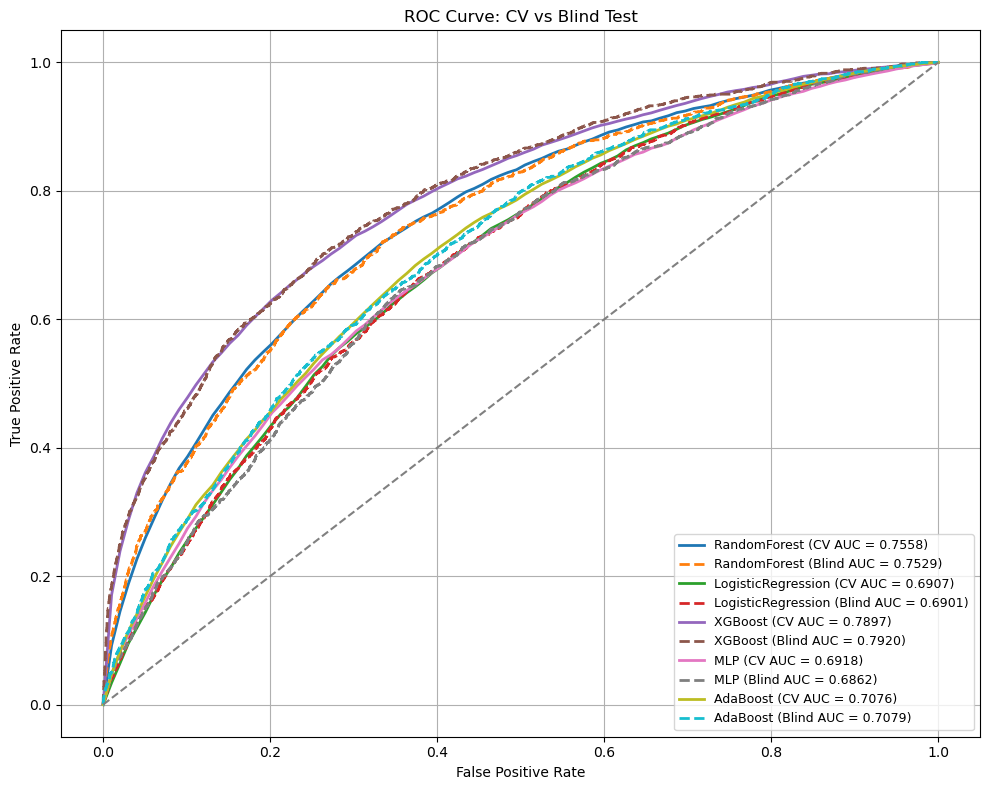

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, average_precision_score,
    matthews_corrcoef, cohen_kappa_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ------------------- Data Preparation -------------------
# Assuming strain_df and blind_df are preloaded pandas DataFrames
X = strain_df.drop(columns=['outcome'])
y = strain_df['outcome']

print(f"Training set shape: {X.shape}")
print(f"Number of positive samples (outcome=1): {(y == 1).sum()}")
print(f"Number of negative samples (outcome=0): {(y == 0).sum()}")

# Drop non-numeric columns and scale features
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) > 0:
    print(f"Dropping non-numeric columns: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Prepare blind set data similarly
X_blind = blind_df.drop(columns=['outcome'])
y_blind = blind_df['outcome']

print(f"Blind set shape: {X_blind.shape}")
print(f"Number of positive samples in blind set (outcome=1): {(y_blind == 1).sum()}")
print(f"Number of negative samples in blind set (outcome=0): {(y_blind == 0).sum()}")

non_numeric_blind = X_blind.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_blind) > 0:
    print(f"Dropping non-numeric columns in blind set: {list(non_numeric_blind)}")
    X_blind = X_blind.drop(columns=non_numeric_blind)

X_blind = pd.DataFrame(scaler.transform(X_blind), columns=X.columns)

# ------------------- Classifiers -------------------
classifiers = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced',
        max_depth=None, min_samples_split=2, min_samples_leaf=3, max_features='sqrt'
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        use_label_encoder=False, eval_metric='logloss', random_state=42,
        max_depth=7, learning_rate=0.05, n_estimators=200,
        subsample=0.8, colsample_bytree=1.0
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100,), max_iter=300, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=42
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
save_dir = "/Users/janat/NSQIP_New/models/presmotegrid/models"
os.makedirs(save_dir, exist_ok=True)

# ------------------- Evaluation -------------------
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    print(f"\n🔍 Classifier: {name}")
    print("Fold\tAcc\tPrec\tRecall\tF1\tAUC\tSpec\tPPV\tMCC\tKappa")

    tprs, aucs = [], []
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    spec_list, ppv_list, mcc_list, kappa_list = [], [], [], []
    mean_fpr = np.linspace(0, 1, 100)

    best_auc = 0
    best_model = None

    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        precision = report["macro avg"]["precision"]
        recall = report["macro avg"]["recall"]
        f1 = report["macro avg"]["f1-score"]
        mcc = matthews_corrcoef(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        print(f"{i+1}\t{acc:.4f}\t{precision:.4f}\t{recall:.4f}\t{f1:.4f}\t{roc_auc:.4f}\t{specificity:.4f}\t{ppv:.4f}\t{mcc:.4f}\t{kappa:.4f}")

        acc_list.append(acc)
        prec_list.append(precision)
        rec_list.append(recall)
        f1_list.append(f1)
        aucs.append(roc_auc)
        spec_list.append(specificity)
        ppv_list.append(ppv)
        mcc_list.append(mcc)
        kappa_list.append(kappa)

        # Interpolate TPRs for mean ROC curve
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = clf

    print("Avg\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        np.mean(acc_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list),
        np.mean(aucs), np.mean(spec_list), np.mean(ppv_list), np.mean(mcc_list), np.mean(kappa_list)))

    # Save best model
    model_path = os.path.join(save_dir, f"{name}_best_model.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model for {name} at: {model_path}")

    # Evaluate on blind set
    best_model.fit(X, y)
    y_pred_blind = best_model.predict(X_blind)
    y_proba_blind = best_model.predict_proba(X_blind)[:, 1]

    acc_b = accuracy_score(y_blind, y_pred_blind)
    report_b = classification_report(y_blind, y_pred_blind, output_dict=True, zero_division=0)
    prec_b = report_b["macro avg"]["precision"]
    rec_b = report_b["macro avg"]["recall"]
    f1_b = report_b["macro avg"]["f1-score"]
    mcc_b = matthews_corrcoef(y_blind, y_pred_blind)
    kappa_b = cohen_kappa_score(y_blind, y_pred_blind)

    tn, fp, fn, tp = confusion_matrix(y_blind, y_pred_blind).ravel()
    spec_b = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv_b = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    roc_auc_b = roc_auc_score(y_blind, y_proba_blind)

    print("Blindset\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        acc_b, prec_b, rec_b, f1_b, roc_auc_b, spec_b, ppv_b, mcc_b, kappa_b))

    # Plot ROC curves
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0  # Ensure end point is 1.0
    mean_auc = np.mean(aucs)

    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{name} (CV AUC = {mean_auc:.4f})")
    fpr_b, tpr_b, _ = roc_curve(y_blind, y_proba_blind)
    plt.plot(fpr_b, tpr_b, linestyle='--', lw=2, label=f"{name} (Blind AUC = {roc_auc_b:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CV vs Blind Test")
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


## SMOTE: Synthetic Minority Oversampling Technique

In [57]:
#SMOTE
## Over-sampling the number using SMOTE
import pandas as pd
import numpy as np
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore")

def smote_tomek_binary_target(
    df,
    target_col='outcome',
    target_minority_class=1,
    fixed_target_samples=113969,
    k_neighbors=5,
    random_state=42
):
    """
    Applies SMOTE + Tomek Links to a binary classification dataset to upsample 
    a specific minority class to a target count.
    
    Returns:
        pd.DataFrame with synthetic rows labeled by 'is_synthetic'.
    """

    # Step 1: Split the majority and minority classes
    minority_df = df[df[target_col] == target_minority_class].copy()
    majority_df = df[df[target_col] != target_minority_class].copy()

    current_count = len(minority_df)
    if fixed_target_samples <= current_count:
        print(f"⚠️ Target count ≤ current count for class {target_minority_class}. No SMOTE needed.")
        df['is_synthetic'] = False
        return df.copy()

    # Step 2: Prepare for SMOTE
    X = df.drop(columns=[target_col])
    y = df[target_col]

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X_numeric = X[numeric_cols]

    smote = SMOTE(
        sampling_strategy={target_minority_class: fixed_target_samples},
        k_neighbors=k_neighbors,
        random_state=random_state
    )
    smt = SMOTETomek(smote=smote, random_state=random_state)

    X_resampled, y_resampled = smt.fit_resample(X_numeric, y)

    # Step 3: Tag synthetic rows
    n_original = len(X_numeric)
    n_new = len(X_resampled) - n_original
    synthetic_flags = np.array([False] * n_original + [True] * n_new)

    # Step 4: Reconstruct full DataFrame
    non_numeric_cols = X.columns.difference(numeric_cols)
    if len(non_numeric_cols) > 0:
        replicated_indices = np.random.choice(df.index, size=len(X_resampled), replace=True)
        X_non_numeric = df.loc[replicated_indices, non_numeric_cols].reset_index(drop=True)
    else:
        X_non_numeric = pd.DataFrame(index=range(len(X_resampled)))

    X_res_df = pd.concat([X_non_numeric.reset_index(drop=True),
                          pd.DataFrame(X_resampled, columns=numeric_cols)], axis=1)
    X_res_df[target_col] = y_resampled
    X_res_df['is_synthetic'] = synthetic_flags

    # Step 5: Summary
    print("✅ After Resampling:")
    print(X_res_df[target_col].value_counts())
    print("\n🧬 Synthetic Samples Added:")
    print(X_res_df[X_res_df['is_synthetic']].groupby(target_col).size())

    return X_res_df

In [58]:
#97812, 36)
#Group counts:
 #outcome
#0    91175
#1     6637



df_smote = smote_tomek_binary_target(
    strain_df,
    target_col='outcome',
    target_minority_class=1,
    fixed_target_samples=91175,
    k_neighbors=5,
    random_state=42
)
df_smote

✅ After Resampling:
outcome
0    91094
1    91094
Name: count, dtype: int64

🧬 Synthetic Samples Added:
outcome
1    84376
dtype: int64


,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,fnstatus2,...,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas,outcome,is_synthetic
0,24.823249,1,5,0,1,61.000000,1,1,2,0,...,16.000000,47.000000,7.400000,45.100000,293.000000,31.177778,1.135185,1,0,False
1,31.780592,0,2,0,1,80.000000,1,0,2,0,...,32.000000,98.000000,7.600000,41.800000,321.000000,21.300000,1.050000,2,0,False
2,20.045440,0,5,0,1,47.000000,1,0,2,0,...,17.000000,73.000000,5.600000,45.000000,182.000000,26.525000,1.050000,0,0,False
3,20.466036,0,5,0,1,67.000000,1,0,2,0,...,21.000000,41.000000,3.500000,37.500000,235.000000,26.790701,1.000000,1,0,False
4,45.511019,1,5,0,1,42.000000,1,1,2,0,...,17.520833,93.565972,7.800000,36.400000,211.000000,26.077302,1.036758,2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182183,25.427365,1,5,0,1,54.630138,1,0,2,0,...,30.647259,45.621955,6.272260,48.046233,296.462328,30.762382,1.213553,1,1,True
182184,26.120473,0,4,0,1,77.877554,1,0,2,0,...,34.484314,101.899589,5.061223,44.785712,154.244892,28.024846,1.100000,1,1,True
182185,29.329491,1,5,0,1,72.405558,1,0,2,0,...,38.775755,95.291497,6.712146,44.105558,186.414822,29.223882,0.961019,1,1,True
182186,29.097431,0,5,1,1,50.226046,1,0,2,0,...,23.000000,50.486503,5.342510,38.993859,304.226046,25.792868,1.003256,1,1,True


In [59]:
group_counts = df_smote['outcome'].value_counts()
print("Group counts:\n", group_counts)

Group counts:
 outcome
0    91094
1    91094
Name: count, dtype: int64


## PCA analysis for SMOTE DATASET

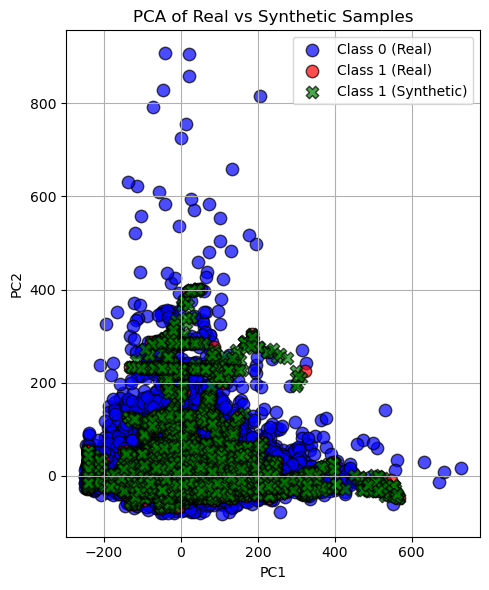

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Copy the resampled dataframe
#df_subset = df_smote.iloc[:120000].copy()
df_subset = df_smote.copy()
# Drop metadata columns
X = df_subset.drop(columns=['is_synthetic', 'outcome'], errors='ignore')

# PCA transformation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Add PCA coordinates
df_subset['PC1'] = X_pca[:, 0]
df_subset['PC2'] = X_pca[:, 1]

# Plotting
plt.figure(figsize=(5, 6))

# Marker mapping
markers = {'real': 'o', 'synthetic': 'X'}

# Custom color mapping (tuple: (class, is_synthetic) -> color)
color_map = {
    (0, False): 'blue',
    (0, True): 'blue',
    (1, False): 'red',
    (1, True): 'green',  # Class 1 Synthetic → Green
}

for synth_status in [False, True]:
    subset = df_subset[df_subset['is_synthetic'] == synth_status]
    label_suffix = 'Synthetic' if synth_status else 'Real'
    for class_val in sorted(subset['outcome'].unique()):
        class_subset = subset[subset['outcome'] == class_val]
        plt.scatter(
            class_subset['PC1'],
            class_subset['PC2'],
            label=f'Class {class_val} ({label_suffix})',
            marker=markers['synthetic' if synth_status else 'real'],
            color=color_map.get((class_val, synth_status), 'gray'),
            alpha=0.7,
            edgecolor='k',
            s=80
        )

plt.title('PCA of Real vs Synthetic Samples')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



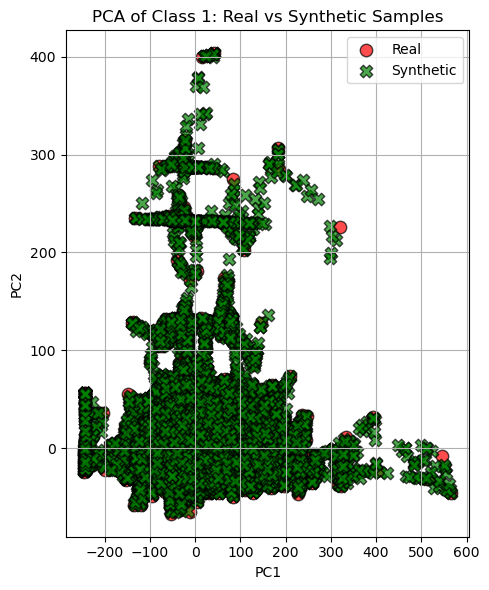

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Filter only Class 1 samples
df_subset = df_smote[df_smote['outcome'] == 1].copy()
#df_smote.iloc[:120000]
#df_subset = df_smote.iloc[:1000000][df_smote['outcome'] == 1].copy()
# Drop metadata columns
X = df_subset.drop(columns=['is_synthetic', 'outcome'], errors='ignore')

# Perform PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Add PCA components to the DataFrame
df_subset['PC1'] = X_pca[:, 0]
df_subset['PC2'] = X_pca[:, 1]

# Plotting setup
plt.figure(figsize=(5, 6))

# Marker and color settings
markers = {False: 'o', True: 'X'}          # Real = o, Synthetic = X
colors = {False: 'red', True: 'green'}     # Real = red, Synthetic = green

for synth_status in [False, True]:
    subset = df_subset[df_subset['is_synthetic'] == synth_status]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label='Synthetic' if synth_status else 'Real',
        marker=markers[synth_status],
        color=colors[synth_status],
        alpha=0.7,
        edgecolor='k',
        s=80
    )

plt.title('PCA of Class 1: Real vs Synthetic Samples')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## XGBoost hyperparameter grid tunning

In [64]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np
from itertools import product

# Prepare data
X = df_smote.drop(columns=['outcome','is_synthetic'])
y = df_smote['outcome']

non_numeric = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric):
    X = X.drop(columns=non_numeric)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Generate all possible combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Manual grid search
best_score = 0
best_params = None

for params in combinations:
    scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **params
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        scores.append(acc)

    mean_acc = np.mean(scores)
    print(f"Params: {params} → Accuracy: {mean_acc:.4f}")

    if mean_acc > best_score:
        best_score = mean_acc
        best_params = params

print("\n🏁 Best Parameters Found:")
print(best_params)
print(f"📈 Best Cross-Validated Accuracy: {best_score:.4f}")


Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 0.8} → Accuracy: 0.7687
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 1.0} → Accuracy: 0.7642
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0, 'colsample_bytree': 0.8} → Accuracy: 0.7682
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 1.0, 'colsample_bytree': 1.0} → Accuracy: 0.7659
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8} → Accuracy: 0.7825
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 1.0} → Accuracy: 0.7822
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.8} → Accuracy: 0.7824
Params: {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 1

## SMOTE with Cross Validation Approach

Dimension of X: (182188, 34)
Number of positive samples (outcome=1): 91094
Number of negative samples (outcome=0): 91094

🔍 Classifier: RandomForest
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
1	0.9024	0.9029	0.9024	0.9023	0.9637	0.8838	0.8880	0.8053	0.8048
2	0.9077	0.9084	0.9077	0.9077	0.9662	0.8871	0.8916	0.8161	0.8154
3	0.9046	0.9050	0.9046	0.9045	0.9647	0.8870	0.8909	0.8096	0.8091
4	0.9078	0.9084	0.9078	0.9078	0.9648	0.8886	0.8927	0.8162	0.8156
5	0.9035	0.9042	0.9035	0.9035	0.9640	0.8831	0.8877	0.8077	0.8070
Avg	0.9052	0.9058	0.9052	0.9052	0.9647	0.8859	0.8902	0.8110	0.8104
✅ Saved best model for RandomForest at: /Users/janat/NSQIP_New/models/smote/models/RandomForest_best_model.pkl
Blindset	0.8444	0.5550	0.5985	0.5643	0.7048	0.8830	0.1634	0.1472	0.1381

🔍 Classifier: LogisticRegression
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
1	0.7628	0.7649	0.7628	0.7623	0.8341	0.7181	0.7412	0.5277	0.5256
2	0.7641	0.7667	0.7641	0.7635	0.8358	0.7147	0.7404	0.5308	0.5282
3	0.7658	0.7684	0.

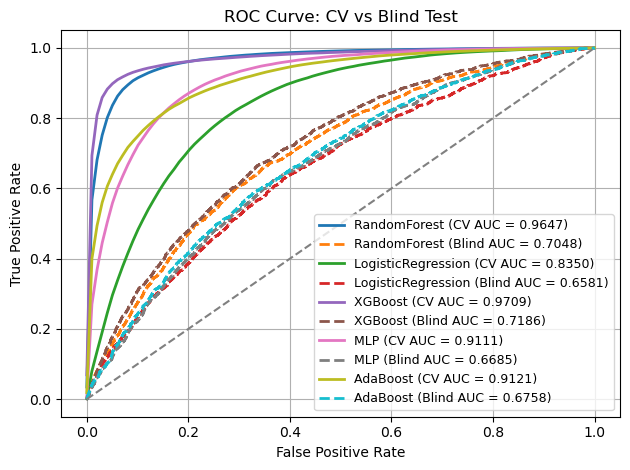

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    average_precision_score, matthews_corrcoef, cohen_kappa_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ------------------- Data Preparation -------------------
X = df_smote.drop(columns=['outcome','is_synthetic'])
y = df_smote['outcome']


print(f"Dimension of X: {X.shape}")
print(f"Number of positive samples (outcome=1): {(y == 1).sum()}")
print(f"Number of negative samples (outcome=0): {(y == 0).sum()}")



X = X.drop(columns=X.select_dtypes(include=['object', 'category']).columns)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_blind = blind_df.drop(columns=['outcome'])
y_blind = blind_df['outcome']
X_blind = X_blind.drop(columns=X_blind.select_dtypes(include=['object', 'category']).columns)
X_blind = pd.DataFrame(scaler.transform(X_blind), columns=X.columns)

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='log2'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=True, eval_metric='logloss', random_state=42, max_depth=7, learning_rate=0.05, n_estimators=200, subsample=0.8, colsample_bytree=0.8),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
save_dir = "/Users/janat/NSQIP_New/models/smote/models"
os.makedirs(save_dir, exist_ok=True)

# ------------------- Evaluation -------------------
for name, clf in classifiers.items():
    print(f"\n🔍 Classifier: {name}")
    print("Fold\tAcc\tPrec\tRecall\tF1\tAUC\tSpec\tPPV\tMCC\tKappa")

    tprs, aucs, pr_aucs = [], [], []
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    spec_list, ppv_list, mcc_list, kappa_list = [], [], [], []
    mean_fpr = np.linspace(0, 1, 100)

    best_auc = 0
    best_model = None

    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        precision = report["macro avg"]["precision"]
        recall = report["macro avg"]["recall"]
        f1 = report["macro avg"]["f1-score"]
        mcc = matthews_corrcoef(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        pr_auc = average_precision_score(y_test, y_proba)

        print(f"{i+1}\t{acc:.4f}\t{precision:.4f}\t{recall:.4f}\t{f1:.4f}\t{roc_auc:.4f}\t{specificity:.4f}\t{ppv:.4f}\t{mcc:.4f}\t{kappa:.4f}")

        acc_list.append(acc)
        prec_list.append(precision)
        rec_list.append(recall)
        f1_list.append(f1)
        aucs.append(roc_auc)
        pr_aucs.append(pr_auc)
        spec_list.append(specificity)
        ppv_list.append(ppv)
        mcc_list.append(mcc)
        kappa_list.append(kappa)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = clf

    print("Avg\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        np.mean(acc_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list),
        np.mean(aucs), np.mean(spec_list), np.mean(ppv_list), np.mean(mcc_list), np.mean(kappa_list)))

    model_path = os.path.join(save_dir, f"{name}_best_model.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model for {name} at: {model_path}")

    best_model.fit(X, y)
    y_pred_blind = best_model.predict(X_blind)
    y_proba_blind = best_model.predict_proba(X_blind)[:, 1]

    acc_b = accuracy_score(y_blind, y_pred_blind)
    report_b = classification_report(y_blind, y_pred_blind, output_dict=True)
    prec_b = report_b["macro avg"]["precision"]
    rec_b = report_b["macro avg"]["recall"]
    f1_b = report_b["macro avg"]["f1-score"]
    mcc_b = matthews_corrcoef(y_blind, y_pred_blind)
    kappa_b = cohen_kappa_score(y_blind, y_pred_blind)

    tn, fp, fn, tp = confusion_matrix(y_blind, y_pred_blind).ravel()
    spec_b = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv_b = tp / (tp + fp) if (tp + fp) > 0 else 0
    roc_auc_b = roc_auc_score(y_blind, y_proba_blind)
    pr_auc_b = average_precision_score(y_blind, y_proba_blind)

    print("Blindset\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        acc_b, prec_b, rec_b, f1_b, roc_auc_b, spec_b, ppv_b, mcc_b, kappa_b))

    fpr_b, tpr_b, _ = roc_curve(y_blind, y_proba_blind)
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{name} (CV AUC = {mean_auc:.4f})")
    plt.plot(fpr_b, tpr_b, linestyle='--', lw=2, label=f"{name} (Blind AUC = {roc_auc_b:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CV vs Blind Test")
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


## SHAP analysis


🔍 Permutation Importance (Top Features by Drop in Accuracy):

Top 27 Features by Permutation Importance for XGBoost:
prsodm: 0.0921
ethnicity_hispanic: 0.0293
race_new: 0.0164
asaclas: 0.0129
prbili: 0.0102
age: 0.0075
smoke: 0.0060
prinr: 0.0057
pralbum: 0.0055
prcreat: 0.0052
prptt: 0.0047
hypermed: 0.0046
pralkph: 0.0043
prhct: 0.0042
prbun: 0.0039
sex: 0.0033
bmi: 0.0029
prsgot: 0.0028
prwbc: 0.0024
diabetes: 0.0022
prplate: 0.0019
steroid: 0.0015
fnstatus2: 0.0007
bleeddis: 0.0006
hxcopd: 0.0005
dyspnea: 0.0002
transt: 0.0000


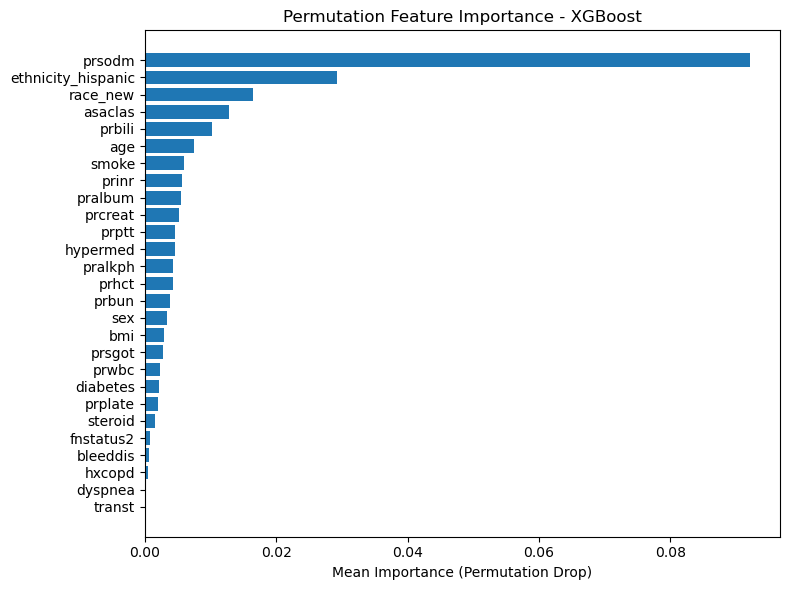


🔍 SHAP Feature Importance (Global Explanations):


100%|===================| 36264/36438 [02:31<00:00]        


Top 36 Features by Mean SHAP Value for XGBoost:
prsodm: 0.9795
asaclas: 0.4318
hypermed: 0.2922
race_new: 0.2554
ethnicity_hispanic: 0.2551
prbili: 0.2390
pralbum: 0.2105
prinr: 0.1910
prhct: 0.1889
age: 0.1842
prptt: 0.1783
sex: 0.1674
pralkph: 0.1245
bmi: 0.1132
smoke: 0.1072
prcreat: 0.1070
prsgot: 0.0998
prbun: 0.0853
diabetes: 0.0730
prwbc: 0.0616
fnstatus2: 0.0407
prplate: 0.0388
bleeddis: 0.0371
steroid: 0.0298
hxcopd: 0.0132
dyspnea: 0.0031
transt: 0.0001
wtloss: 0.0000
hxchf: 0.0000
ventilat: 0.0000
renafail: 0.0000
ascites: 0.0000
dialysis: 0.0000
discancr: 0.0000


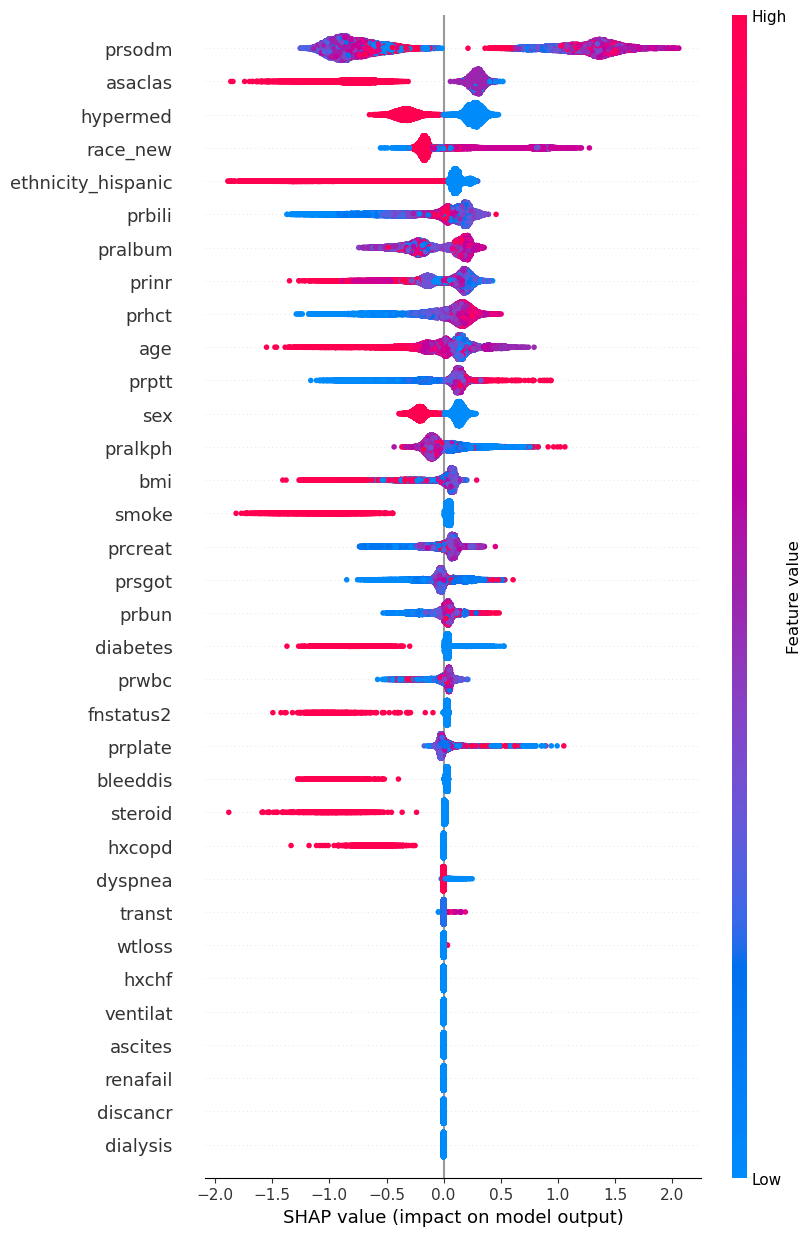

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# ------------------- Load and Prepare Data -------------------
# Assuming df_smote is already defined
X = df_smote.drop(columns=['outcome', 'is_synthetic'])
y = df_smote['outcome']

# Drop non-numeric columns
non_numeric = X.select_dtypes(include=['object', 'category']).columns
X = X.drop(columns=non_numeric)

# Scale numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------- Classifier -------------------
models = {
    'XGBoost': XGBClassifier(
        # use_label_encoder is deprecated, removed it
        eval_metric='logloss',
        random_state=42,
        max_depth=7,
        learning_rate=0.05,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

# ------------------- Permutation Importance -------------------
print("\n🔍 Permutation Importance (Top Features by Drop in Accuracy):")
perm_file = "/Users/janat/NSQIP_New/permutation_importance.csv"
os.makedirs(os.path.dirname(perm_file), exist_ok=True)

for name, model in models.items():
    model.fit(X_train, y_train)
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
    )
    sorted_idx = result.importances_mean.argsort()[::-1]

    top_features = [(X.columns[i], result.importances_mean[i]) 
                    for i in sorted_idx[:35] if result.importances_mean[i] > 0.00]

    print(f"\nTop {len(top_features)} Features by Permutation Importance for {name}:")
    for feature, importance in top_features:
        print(f"{feature}: {importance:.4f}")

    # Plot
    features, importances = zip(*top_features)
    plt.figure(figsize=(8, 6))
    plt.barh(features, importances)
    plt.xlabel("Mean Importance (Permutation Drop)")
    plt.title(f"Permutation Feature Importance - {name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Save to CSV (append mode)
    perm_df = pd.DataFrame(top_features, columns=['Feature', 'PermutationImportance'])
    perm_df['Model'] = name
    perm_df.to_csv(perm_file, index=False, mode='a', header=not os.path.exists(perm_file))

# ------------------- SHAP Importance -------------------
print("\n🔍 SHAP Feature Importance (Global Explanations):")
shap_file = "/Users/janat/NSQIP_New/shap_importance.csv"
os.makedirs(os.path.dirname(shap_file), exist_ok=True)

explainer = shap.Explainer(models['XGBoost'], X_train)
shap_values = explainer(X_test)

# Global SHAP importance
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

print(f"\nTop 36 Features by Mean SHAP Value for XGBoost:")
for feature, importance in shap_importance.head(36).items():
    print(f"{feature}: {importance:.4f}")

# Plot beeswarm
shap.plots.beeswarm(shap_values, max_display=36)

# Save SHAP importance to CSV (append mode)
shap_df = shap_importance.head(36).reset_index()
shap_df.columns = ['Feature', 'MeanSHAP']
shap_df['Model'] = 'XGBoost'
shap_df.to_csv(shap_file, index=False, mode='a', header=not os.path.exists(shap_file))


## POST SHAP & Permutation Importance analysis

In [86]:
top_features

[('prsodm', 0.09207420824414078),
 ('ethnicity_hispanic', 0.02930457214995339),
 ('race_new', 0.016414182995773685),
 ('asaclas', 0.012876667215544247),
 ('prbili', 0.010178934079806834),
 ('age', 0.007472967780888106),
 ('smoke', 0.005958065755529973),
 ('prinr', 0.005730281574180818),
 ('pralbum', 0.005450354026016835),
 ('prcreat', 0.00519787035512379),
 ('prptt', 0.004659970360612576),
 ('hypermed', 0.004616060156978996),
 ('pralkph', 0.004273011691091755),
 ('prhct', 0.004229101487458175),
 ('prbun', 0.003886053021570912),
 ('sex', 0.003345408639332581),
 ('bmi', 0.0029310060925407887),
 ('prsgot', 0.002810253032548471),
 ('prwbc', 0.0023629178330314637),
 ('diabetes', 0.0021543443657720098),
 ('prplate', 0.0019430265107854949),
 ('steroid', 0.0015203908008123769),
 ('fnstatus2', 0.0007327515231352),
 ('bleeddis', 0.0006065096876886944),
 ('hxcopd', 0.00047203468906090726),
 ('dyspnea', 0.00017838520226142184),
 ('transt', 2.7443877271049466e-05)]

In [88]:
selected_feature_names = [feat for feat, val in top_features]
selected_feature_names

['prsodm',
 'ethnicity_hispanic',
 'race_new',
 'asaclas',
 'prbili',
 'age',
 'smoke',
 'prinr',
 'pralbum',
 'prcreat',
 'prptt',
 'hypermed',
 'pralkph',
 'prhct',
 'prbun',
 'sex',
 'bmi',
 'prsgot',
 'prwbc',
 'diabetes',
 'prplate',
 'steroid',
 'fnstatus2',
 'bleeddis',
 'hxcopd',
 'dyspnea',
 'transt']

In [90]:
outcome_col_name = 'outcome'  # or whatever the actual name is
df_selected_features = df_smote[[outcome_col_name] + selected_feature_names]
df_selected_features

,outcome,prsodm,ethnicity_hispanic,race_new,asaclas,prbili,age,smoke,prinr,pralbum,...,prsgot,prwbc,diabetes,prplate,steroid,fnstatus2,bleeddis,hxcopd,dyspnea,transt
0,0,138.000000,0,5,1,0.600000,61.000000,1,1.135185,4.000000,...,16.000000,7.400000,1,293.000000,0,0,0,1,2,1
1,0,145.000000,0,2,2,0.600000,80.000000,0,1.050000,4.200000,...,32.000000,7.600000,1,321.000000,0,0,0,0,2,1
2,0,139.000000,0,5,0,0.800000,47.000000,0,1.050000,4.600000,...,17.000000,5.600000,1,182.000000,0,0,0,0,2,1
3,0,142.000000,0,5,1,0.800000,67.000000,0,1.000000,4.300000,...,21.000000,3.500000,1,235.000000,0,0,0,0,2,1
4,0,139.000000,0,5,2,0.500000,42.000000,1,1.036758,3.915972,...,17.520833,7.800000,1,211.000000,0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182183,1,143.000000,0,5,1,0.740477,54.630138,0,1.213553,4.213605,...,30.647259,6.272260,1,296.462328,0,0,0,0,2,1
182184,1,139.625851,0,4,1,0.499368,77.877554,0,1.100000,4.131387,...,34.484314,5.061223,1,154.244892,0,0,0,0,2,1
182185,1,139.184251,0,5,1,0.691896,72.405558,0,0.961019,3.203349,...,38.775755,6.712146,1,186.414822,0,0,0,0,2,1
182186,1,141.095817,1,5,1,0.422605,50.226046,0,1.003256,4.416093,...,23.000000,5.342510,1,304.226046,0,0,0,0,2,1


In [92]:
outcome_col_name = 'outcome'  # or whatever the actual name is
df_blind_selected_features = blind_df[[outcome_col_name] + selected_feature_names]
df_blind_selected_features

,outcome,prsodm,ethnicity_hispanic,race_new,asaclas,prbili,age,smoke,prinr,pralbum,...,prsgot,prwbc,diabetes,prplate,steroid,fnstatus2,bleeddis,hxcopd,dyspnea,transt
5419,0,140.0,1,4,0,0.300000,53.0,0,1.000000,4.800000,...,20.000000,7.30,1,401.0,0,0,0,0,2,1
86087,0,142.0,0,5,1,0.416667,62.0,0,2.600000,3.916667,...,17.583333,3.73,1,178.0,0,0,0,0,2,1
89329,0,144.0,0,5,1,0.400000,65.0,1,1.044444,3.900000,...,22.777778,8.64,1,217.0,0,0,0,0,2,1
14759,0,142.0,0,5,2,0.400000,76.0,0,1.110000,4.500000,...,11.000000,35.70,1,197.0,0,0,0,0,2,1
111329,0,138.0,0,5,2,1.619136,82.0,0,0.980894,4.366667,...,24.358025,6.85,1,262.0,0,1,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37095,0,141.0,0,5,1,0.500000,75.0,0,1.000000,4.200000,...,17.000000,4.10,1,171.0,0,0,0,0,2,1
79709,0,137.0,0,5,1,0.823045,59.0,0,1.274577,4.133604,...,21.604944,4.70,1,278.0,0,0,0,0,2,1
71072,0,140.0,1,5,1,0.992386,67.0,1,0.900000,3.499609,...,25.249392,6.92,1,423.0,0,0,0,0,2,1
79905,0,144.0,0,5,2,0.555556,77.0,0,0.900000,3.977778,...,22.111111,8.90,2,224.0,0,0,0,0,2,1


Dimension of X: (182188, 27)
Number of positive samples (outcome=1): 91094
Number of negative samples (outcome=0): 91094

🔍 Classifier: RandomForest
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
1	0.9025	0.9030	0.9025	0.9024	0.9629	0.8849	0.8888	0.8054	0.8049
2	0.9089	0.9095	0.9089	0.9088	0.9666	0.8885	0.8929	0.8184	0.8177
3	0.9046	0.9051	0.9046	0.9045	0.9648	0.8872	0.8910	0.8096	0.8092
4	0.9053	0.9061	0.9053	0.9053	0.9644	0.8836	0.8885	0.8114	0.8106
5	0.9021	0.9028	0.9021	0.9021	0.9632	0.8815	0.8862	0.8049	0.8043
Avg	0.9047	0.9053	0.9047	0.9046	0.9644	0.8852	0.8895	0.8100	0.8093
✅ Saved best model for RandomForest at: /Users/janat/NSQIP_New/models/smote/selected/models/RandomForest_best_model.pkl
Blindset	0.8475	0.5547	0.5951	0.5640	0.7045	0.8871	0.1635	0.1443	0.1363

🔍 Classifier: LogisticRegression
Fold	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
1	0.7624	0.7644	0.7624	0.7619	0.8333	0.7187	0.7413	0.5267	0.5247
2	0.7634	0.7660	0.7634	0.7628	0.8350	0.7139	0.7397	0.5294	0.5268
3	0.7661	

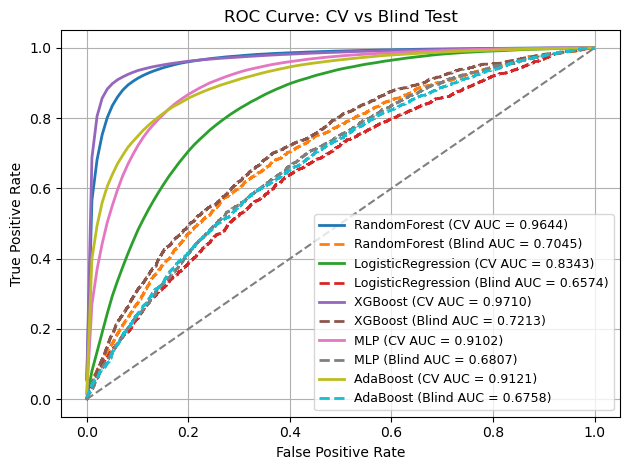

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    average_precision_score, matthews_corrcoef, cohen_kappa_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ------------------- Data Preparation -------------------
X = df_selected_features.drop(columns=['outcome'])
y = df_selected_features['outcome']


print(f"Dimension of X: {X.shape}")
print(f"Number of positive samples (outcome=1): {(y == 1).sum()}")
print(f"Number of negative samples (outcome=0): {(y == 0).sum()}")



X = X.drop(columns=X.select_dtypes(include=['object', 'category']).columns)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_blind = df_blind_selected_features.drop(columns=['outcome'])
y_blind = df_blind_selected_features['outcome']
X_blind = X_blind.drop(columns=X_blind.select_dtypes(include=['object', 'category']).columns)
X_blind = pd.DataFrame(scaler.transform(X_blind), columns=X.columns)

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='log2'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=True, eval_metric='logloss', random_state=42, max_depth=7, learning_rate=0.05, n_estimators=200, subsample=0.8, colsample_bytree=0.8),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
save_dir = "/Users/janat/NSQIP_New/models/smote/selected/models"
os.makedirs(save_dir, exist_ok=True)

# ------------------- Evaluation -------------------
for name, clf in classifiers.items():
    print(f"\n🔍 Classifier: {name}")
    print("Fold\tAcc\tPrec\tRecall\tF1\tAUC\tSpec\tPPV\tMCC\tKappa")

    tprs, aucs, pr_aucs = [], [], []
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    spec_list, ppv_list, mcc_list, kappa_list = [], [], [], []
    mean_fpr = np.linspace(0, 1, 100)

    best_auc = 0
    best_model = None

    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        precision = report["macro avg"]["precision"]
        recall = report["macro avg"]["recall"]
        f1 = report["macro avg"]["f1-score"]
        mcc = matthews_corrcoef(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        pr_auc = average_precision_score(y_test, y_proba)

        print(f"{i+1}\t{acc:.4f}\t{precision:.4f}\t{recall:.4f}\t{f1:.4f}\t{roc_auc:.4f}\t{specificity:.4f}\t{ppv:.4f}\t{mcc:.4f}\t{kappa:.4f}")

        acc_list.append(acc)
        prec_list.append(precision)
        rec_list.append(recall)
        f1_list.append(f1)
        aucs.append(roc_auc)
        pr_aucs.append(pr_auc)
        spec_list.append(specificity)
        ppv_list.append(ppv)
        mcc_list.append(mcc)
        kappa_list.append(kappa)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = clf

    print("Avg\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        np.mean(acc_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list),
        np.mean(aucs), np.mean(spec_list), np.mean(ppv_list), np.mean(mcc_list), np.mean(kappa_list)))

    model_path = os.path.join(save_dir, f"{name}_best_model.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model for {name} at: {model_path}")

    best_model.fit(X, y)
    y_pred_blind = best_model.predict(X_blind)
    y_proba_blind = best_model.predict_proba(X_blind)[:, 1]

    acc_b = accuracy_score(y_blind, y_pred_blind)
    report_b = classification_report(y_blind, y_pred_blind, output_dict=True)
    prec_b = report_b["macro avg"]["precision"]
    rec_b = report_b["macro avg"]["recall"]
    f1_b = report_b["macro avg"]["f1-score"]
    mcc_b = matthews_corrcoef(y_blind, y_pred_blind)
    kappa_b = cohen_kappa_score(y_blind, y_pred_blind)

    tn, fp, fn, tp = confusion_matrix(y_blind, y_pred_blind).ravel()
    spec_b = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv_b = tp / (tp + fp) if (tp + fp) > 0 else 0
    roc_auc_b = roc_auc_score(y_blind, y_proba_blind)
    pr_auc_b = average_precision_score(y_blind, y_proba_blind)

    print("Blindset\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}".format(
        acc_b, prec_b, rec_b, f1_b, roc_auc_b, spec_b, ppv_b, mcc_b, kappa_b))

    fpr_b, tpr_b, _ = roc_curve(y_blind, y_proba_blind)
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{name} (CV AUC = {mean_auc:.4f})")
    plt.plot(fpr_b, tpr_b, linestyle='--', lw=2, label=f"{name} (Blind AUC = {roc_auc_b:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CV vs Blind Test")
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


In [98]:

# Load the external validation set (Blindset2)
blindset2 = pd.read_csv('/Users/janat/NSQIP_New/tka_data_2014_2016.csv')

# Show dataset dimensions
print(f"✅ blindset2 shape: {blindset2.shape}")

# Show value counts of the target column
print("\n✅ Outcome class distribution:")
print(blindset2['outcome'].value_counts())

# If you want percentages too:
print("\n✅ Outcome class distribution (percent):")
print(blindset2['outcome'].value_counts(normalize=True) * 100)


✅ blindset2 shape: (20649, 35)

✅ Outcome class distribution:
outcome
0    20428
1      221
Name: count, dtype: int64

✅ Outcome class distribution (percent):
outcome
0    98.92973
1     1.07027
Name: proportion, dtype: float64


In [100]:
blindset2

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
0,0,30.824839,female,Black or African American,No,Not transferred (admitted from home),56,NO,No,No,...,4.3,0.4000,17.0,98.0,10.0,35.0,288.0,28.4,0.10,2-Mild Disturb
1,0,26.430792,male,White,No,Not transferred (admitted from home),65,NO,No,No,...,4.4,0.8000,15.0,69.0,6.5,45.2,220.0,29.0,0.10,1-No Disturb
2,0,30.102509,female,Unknown/Not Reported,Unknown,Not transferred (admitted from home),76,NO,No,No,...,4.3,0.3509,19.0,70.0,7.5,42.0,309.0,26.5,0.30,2-Mild Disturb
3,0,28.726814,female,White,No,Not transferred (admitted from home),30,NO,No,No,...,3.6,0.8000,18.0,44.0,7.2,33.8,278.0,24.3,0.39,2-Mild Disturb
4,0,37.441690,female,White,No,Not transferred (admitted from home),63,NON-INSULIN,No,No,...,3.9,0.4000,29.0,112.0,7.7,39.3,278.0,27.6,0.68,3-Severe Disturb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20644,0,37.271479,female,White,No,Not transferred (admitted from home),64,NON-INSULIN,No,No,...,4.2,0.4000,19.0,93.0,6.0,42.2,204.0,28.0,9.80,3-Severe Disturb
20645,0,29.856520,male,White,No,Not transferred (admitted from home),67,NO,No,No,...,3.9,0.5000,18.0,44.0,7.4,39.4,232.0,10.3,10.00,2-Mild Disturb
20646,0,24.199951,female,White,No,Not transferred (admitted from home),74,NO,No,No,...,4.3,0.6000,25.0,66.0,4.8,39.6,216.0,25.7,10.00,2-Mild Disturb
20647,0,23.294675,female,White,No,Not transferred (admitted from home),65,NO,No,No,...,3.9,0.6000,25.0,90.0,6.4,40.0,351.0,26.0,10.00,2-Mild Disturb


In [102]:
blindset_df2 = preprocess_dataframe(blindset2, categorical_columns, numerical_columns)
blindset_df2

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
0,0,30.824839,0,2,0,1,56.0,1,0,2,...,4.3,0.4000,17.0,98.0,10.0,35.0,288.0,28.4,0.10,1
1,0,26.430792,1,5,0,1,65.0,1,0,2,...,4.4,0.8000,15.0,69.0,6.5,45.2,220.0,29.0,0.10,0
2,0,30.102509,0,4,1,1,76.0,1,0,2,...,4.3,0.3509,19.0,70.0,7.5,42.0,309.0,26.5,0.30,1
3,0,28.726814,0,5,0,1,30.0,1,0,2,...,3.6,0.8000,18.0,44.0,7.2,33.8,278.0,24.3,0.39,1
4,0,37.441690,0,5,0,1,63.0,2,0,2,...,3.9,0.4000,29.0,112.0,7.7,39.3,278.0,27.6,0.68,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20644,0,37.271479,0,5,0,1,64.0,2,0,2,...,4.2,0.4000,19.0,93.0,6.0,42.2,204.0,28.0,9.80,2
20645,0,29.856520,1,5,0,1,67.0,1,0,2,...,3.9,0.5000,18.0,44.0,7.4,39.4,232.0,10.3,10.00,1
20646,0,24.199951,0,5,0,1,74.0,1,0,2,...,4.3,0.6000,25.0,66.0,4.8,39.6,216.0,25.7,10.00,1
20647,0,23.294675,0,5,0,1,65.0,1,0,2,...,3.9,0.6000,25.0,90.0,6.4,40.0,351.0,26.0,10.00,1


In [104]:
blindset_df2_cleaned= replace_neg99_with_local_avg(blindset_df2, window=2, placeholder=-99)
blindset_df2_cleaned

,outcome,bmi,sex,race_new,ethnicity_hispanic,transt,age,diabetes,smoke,dyspnea,...,pralbum,prbili,prsgot,pralkph,prwbc,prhct,prplate,prptt,prinr,asaclas
0,0,30.824839,0,2,0,1,56.0,1,0,2,...,4.3,0.4000,17.0,98.0,10.0,35.0,288.0,28.4,0.10,1
1,0,26.430792,1,5,0,1,65.0,1,0,2,...,4.4,0.8000,15.0,69.0,6.5,45.2,220.0,29.0,0.10,0
2,0,30.102509,0,4,1,1,76.0,1,0,2,...,4.3,0.3509,19.0,70.0,7.5,42.0,309.0,26.5,0.30,1
3,0,28.726814,0,5,0,1,30.0,1,0,2,...,3.6,0.8000,18.0,44.0,7.2,33.8,278.0,24.3,0.39,1
4,0,37.441690,0,5,0,1,63.0,2,0,2,...,3.9,0.4000,29.0,112.0,7.7,39.3,278.0,27.6,0.68,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20644,0,37.271479,0,5,0,1,64.0,2,0,2,...,4.2,0.4000,19.0,93.0,6.0,42.2,204.0,28.0,9.80,2
20645,0,29.856520,1,5,0,1,67.0,1,0,2,...,3.9,0.5000,18.0,44.0,7.4,39.4,232.0,10.3,10.00,1
20646,0,24.199951,0,5,0,1,74.0,1,0,2,...,4.3,0.6000,25.0,66.0,4.8,39.6,216.0,25.7,10.00,1
20647,0,23.294675,0,5,0,1,65.0,1,0,2,...,3.9,0.6000,25.0,90.0,6.4,40.0,351.0,26.0,10.00,1


In [106]:
outcome_col_name = 'outcome'  # or whatever the actual name is
df_blindset2_selected_features = blindset_df2_cleaned[[outcome_col_name] + selected_feature_names]
df_blindset2_selected_features

,outcome,prsodm,ethnicity_hispanic,race_new,asaclas,prbili,age,smoke,prinr,pralbum,...,prsgot,prwbc,diabetes,prplate,steroid,fnstatus2,bleeddis,hxcopd,dyspnea,transt
0,0,143.0,0,2,1,0.4000,56.0,0,0.10,4.3,...,17.0,10.0,1,288.0,0,0,0,0,2,1
1,0,143.0,0,5,0,0.8000,65.0,0,0.10,4.4,...,15.0,6.5,1,220.0,0,0,0,0,2,1
2,0,138.0,1,4,1,0.3509,76.0,0,0.30,4.3,...,19.0,7.5,1,309.0,0,0,0,0,2,1
3,0,139.0,0,5,1,0.8000,30.0,0,0.39,3.6,...,18.0,7.2,1,278.0,1,0,0,0,2,1
4,0,138.0,0,5,2,0.4000,63.0,0,0.68,3.9,...,29.0,7.7,2,278.0,0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20644,0,142.0,0,5,2,0.4000,64.0,0,9.80,4.2,...,19.0,6.0,2,204.0,0,0,0,0,2,1
20645,0,138.0,0,5,1,0.5000,67.0,0,10.00,3.9,...,18.0,7.4,1,232.0,0,0,0,0,2,1
20646,0,138.0,0,5,1,0.6000,74.0,0,10.00,4.3,...,25.0,4.8,1,216.0,0,0,0,0,2,1
20647,0,140.0,0,5,1,0.6000,65.0,0,10.00,3.9,...,25.0,6.4,1,351.0,0,0,0,0,2,1



Summary Metrics (copy and paste into Word → Text to Table):
Model	Acc	Prec	Recall	F1	AUC	Spec	PPV	MCC	Kappa
AdaBoost	0.8575	0.0143	0.181	0.0265	0.59	0.8648	0.0143	0.0138	0.0068
LogisticRegression	0.7132	0.0138	0.3665	0.0266	0.5798	0.7169	0.0138	0.019	0.0061
MLP	0.7861	0.0139	0.2715	0.0265	0.5787	0.7917	0.0139	0.016	0.0062
XGBoost	0.9831	0.0153	0.009	0.0114	0.6039	0.9937	0.0153	0.0035	0.0034
RandomForest	0.9122	0.0146	0.1086	0.0258	0.5837	0.9208	0.0146	0.0112	0.007



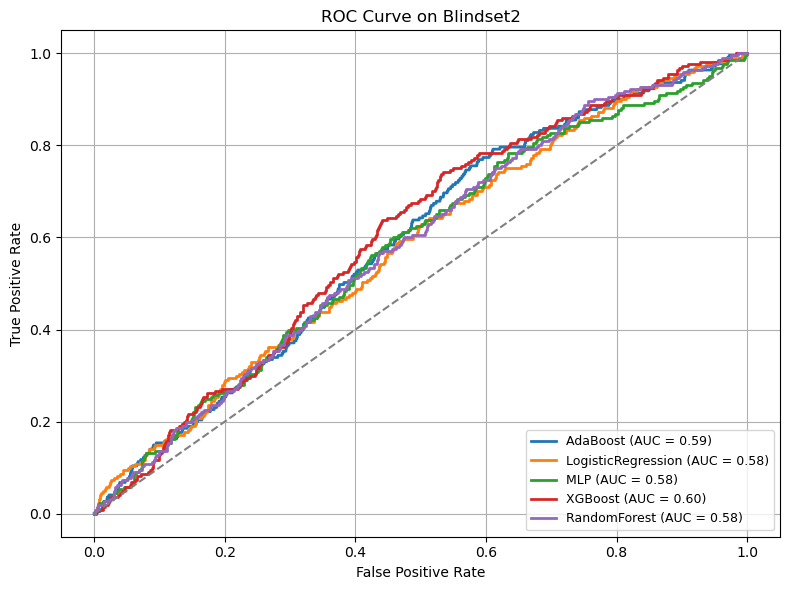

In [108]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, matthews_corrcoef, cohen_kappa_score
)

# ----------------- Load and Preprocess Blindset2 -----------------
X_blind2 = df_blindset2_selected_features.drop(columns=['outcome'])
y_blind2 = df_blindset2_selected_features['outcome']

X_blind2 = X_blind2.drop(columns=X_blind2.select_dtypes(include=['object', 'category']).columns)
X_blind2 = pd.DataFrame(scaler.transform(X_blind2), columns=X.columns)

# ----------------- Load All Models -----------------
model_dir1 = "/Users/janat/NSQIP_New/models/smote/selected/models"
model_files = [f for f in os.listdir(model_dir1) if f.endswith("_best_model.pkl")]

summary_metrics = []

plt.figure(figsize=(8, 6))

for model_file in model_files:
    model_path = os.path.join(model_dir1, model_file)
    model_name = model_file.replace("_best_model.pkl", "")
    model = joblib.load(model_path)

    y_pred = model.predict(X_blind2)
    y_proba = model.predict_proba(X_blind2)[:, 1]

    # Metrics
    acc = accuracy_score(y_blind2, y_pred)
    roc_auc = roc_auc_score(y_blind2, y_proba)
    mcc = matthews_corrcoef(y_blind2, y_pred)
    kappa = cohen_kappa_score(y_blind2, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_blind2, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = ppv
    f1 = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0

    summary_metrics.append({
        "Model": model_name,
        "Acc": acc,
        "Prec": prec,
        "Recall": recall,
        "F1": f1,
        "AUC": roc_auc,
        "Spec": spec,
        "PPV": ppv,
        "MCC": mcc,
        "Kappa": kappa
    })

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_blind2, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.2f})")

# ----------------- Tab-delimited Summary Output -----------------
summary_df = pd.DataFrame(summary_metrics)
summary_df = summary_df[["Model", "Acc", "Prec", "Recall", "F1", "AUC", "Spec", "PPV", "MCC", "Kappa"]]

print("\nSummary Metrics (copy and paste into Word → Text to Table):")
print(summary_df.round(4).to_csv(sep="\t", index=False))

# ----------------- Final ROC Plot -----------------
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Blindset2")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


Balanced class counts:
outcome
1    221
0    221
Name: count, dtype: int64


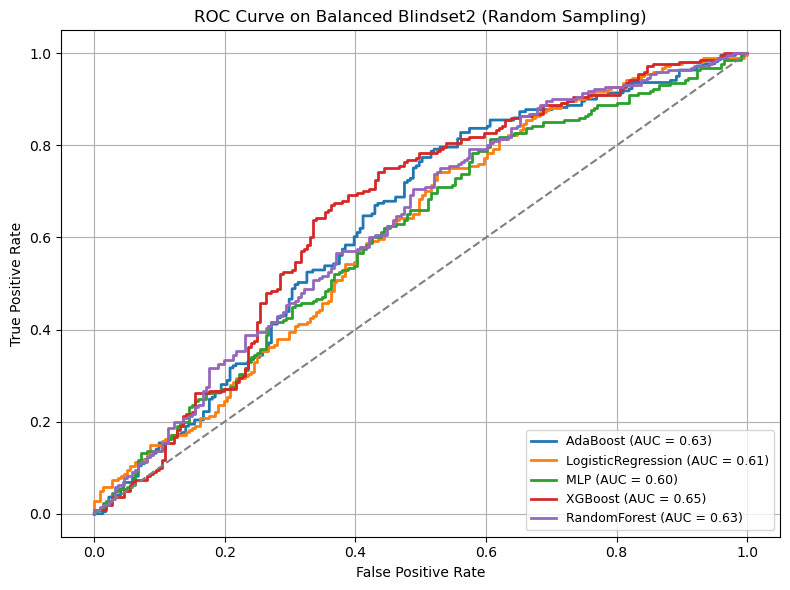

In [109]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, matthews_corrcoef, cohen_kappa_score
)

# ----------------- Load and Preprocess Blindset2 -----------------
X_blind2 = df_blindset2_selected_features.drop(columns=['outcome'])
y_blind2 = df_blindset2_selected_features['outcome']

# Drop non-numeric columns and scale
X_blind2 = X_blind2.drop(columns=X_blind2.select_dtypes(include=['object', 'category']).columns)
X_blind2 = pd.DataFrame(scaler.transform(X_blind2), columns=X.columns)

# Combine X and y into a single DataFrame
df_blind2 = X_blind2.copy()
df_blind2['outcome'] = y_blind2.values

# Separate classes
class0_df = df_blind2[df_blind2['outcome'] == 0]
class1_df = df_blind2[df_blind2['outcome'] == 1]

# Number of samples in minority class (class 1)
n_minority = len(class1_df)

# Randomly sample equal number from class 0 (without replacement)
class0_sampled = class0_df.sample(n=n_minority, random_state=42)

# Combine sampled class 0 and all class 1 samples
df_balanced = pd.concat([class0_sampled, class1_df]).sample(frac=1, random_state=42)  # Shuffle rows

X_bal = df_balanced.drop(columns=['outcome'])
y_bal = df_balanced['outcome']

print(f"Balanced class counts:\n{y_bal.value_counts()}")

# ----------------- Load All Models -----------------
model_dir1 = "/Users/janat/NSQIP_New/models/smote/selected/models"
model_files = [f for f in os.listdir(model_dir1) if f.endswith("_best_model.pkl")]

summary_metrics = []

plt.figure(figsize=(8, 6))

for model_file in model_files:
    model_path = os.path.join(model_dir1, model_file)
    model_name = model_file.replace("_best_model.pkl", "")
    model = joblib.load(model_path)

    y_pred = model.predict(X_bal)
    y_proba = model.predict_proba(X_bal)[:, 1]

    # Metrics
    acc = accuracy_score(y_bal, y_pred)
    roc_auc = roc_auc_score(y_bal, y_proba)
    pr_auc = average_precision_score(y_bal, y_proba)
    mcc = matthews_corrcoef(y_bal, y_pred)
    kappa = cohen_kappa_score(y_bal, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_bal, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = ppv
    f1 = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0

    summary_metrics.append({
        "Model": model_name,
        "Acc": acc,
        "Prec": prec,
        "Recall": recall,
        "F1": f1,
        "AUC": roc_auc,
        "Spec": spec,
        "PPV": ppv,
        "MCC": mcc,
        "Kappa": kappa
    })

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_bal, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.2f})")

# ----------------- Tab-delimited Summary Output -----------------
summary_df = pd.DataFrame(summary_metrics)
summary_df = summary_df[["Model", "Acc", "Prec", "Recall", "F1", "AUC", "Spec", "PPV", "MCC", "Kappa"]]


# ----------------- Final ROC Plot -----------------
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Balanced Blindset2 (Random Sampling)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()
